# Bilderklassifizierungsalgorithmus

## Bibliotheken

In [4]:
import pandas as pd
import urllib
import os
import PIL
import shutil
import numpy as np
%matplotlib inline

## Ordnerstruktur anlegen

In [5]:
basedir = r'Nuts'
dir_dict = {
    'csv' : os.path.join(basedir,'csv'),
    'DataSet' : os.path.join(basedir,'DataSet'),
    'toDetect' : os.path.join(basedir,'toDetect'),
    'download': os.path.join(basedir,'download'),
    'train':  os.path.join(basedir,'test'),
    'test':  os.path.join(basedir,'test'),
    'valid': os.path.join(basedir,'valid'),

    'train_almonds': os.path.join(basedir,'train','almonds'),
    'train_brazil_nuts': os.path.join(basedir,'train','brazil_nuts'),
    'train_cashews': os.path.join(basedir,'train','cashews'),
    'train_coconut': os.path.join(basedir,'train','coconut'),
    'train_hazelnuts': os.path.join(basedir,'train','hazelnuts'),
    'train_macadamia': os.path.join(basedir,'train','macadamia'),    
    'train_pecans': os.path.join(basedir,'train','pecans'),
    'train_pine_nuts': os.path.join(basedir,'train','pine_nuts'),
    'train_pistachios': os.path.join(basedir,'train','pistachios'),
    'train_walnuts': os.path.join(basedir,'train','walnuts'),

    'test_almonds': os.path.join(basedir,'test','almonds'),
    'test_brazil_nuts': os.path.join(basedir,'test','brazil_nuts'),
    'test_cashews': os.path.join(basedir,'test','cashews'),
    'test_coconut': os.path.join(basedir,'test','coconut'),
    'test_hazelnuts': os.path.join(basedir,'test','hazelnuts'),
    'test_macadamia': os.path.join(basedir,'test','macadamia'),    
    'test_pecans': os.path.join(basedir,'test','pecans'),
    'test_pine_nuts': os.path.join(basedir,'test','pine_nuts'),
    'test_pistachios': os.path.join(basedir,'test','pistachios'),
    'test_walnuts': os.path.join(basedir,'test','walnuts'),

    'valid_almonds': os.path.join(basedir,'valid','almonds'),
    'valid_brazil_nuts': os.path.join(basedir,'valid','brazil_nuts'),
    'valid_cashews': os.path.join(basedir,'valid','cashews'),
    'valid_coconut': os.path.join(basedir,'valid','coconut'),
    'valid_hazelnuts': os.path.join(basedir,'valid','hazelnuts'),
    'valid_macadamia': os.path.join(basedir,'valid','macadamia'),    
    'valid_pecans': os.path.join(basedir,'valid','pecans'),
    'valid_pine_nuts': os.path.join(basedir,'valid','pine_nuts'),
    'valid_pistachios': os.path.join(basedir,'valid','pistachios'),
    'valid_walnuts': os.path.join(basedir,'valid','walnuts'),
}

# Erzeuge die Verzeichnisse (nur wenn sie noch nicht vorhanden sind)
for key in dir_dict:
    if not os.path.exists(dir_dict[key]): 
        os.makedirs(dir_dict[key])

# Basisdatensatz Download

In [3]:
#Falls gewünscht Bilder Downloaden
#url = "https://raw.githubusercontent.com/dionhagan/naive-bees/master/train_labels.csv"
#urllib.request.urlretrieve(url, os.path.join(dir_dict['download'],'train_labels.csv'))


('biene_hummel\\download\\train_labels.csv',
 <http.client.HTTPMessage at 0x287a0391fd0>)

# Basisdatensatz einlesen

In [6]:
df = pd.read_csv(os.path.join(dir_dict['csv'],'tree_nuts.csv'))
df.info()
print(df.head(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1263 entries, 0 to 1262
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class index  1263 non-null   int64 
 1   filepaths    1263 non-null   object
 2   labels       1263 non-null   object
 3   data set     1263 non-null   object
dtypes: int64(1), object(3)
memory usage: 39.6+ KB
   class index              filepaths   labels data set
0            0  train/almonds/001.jpg  almonds    train
1            0  train/almonds/002.jpg  almonds    train
2            0  train/almonds/003.jpg  almonds    train
3            0  train/almonds/004.jpg  almonds    train
4            0  train/almonds/005.jpg  almonds    train


# Falls Geladen, Klassen anzeigen

In [8]:
#df = df.sort_values(['class index'])
#df['class'] = np.where(df['labels']==1,'almonds','brazil nuts','brazil nuts','cashews','coconut','hazelnuts','macadamia','pecans','pine nuts','pistachios','walnuts')
#print(df.head(5))

df = df.sort_values(['labels'])

print(df.head(5))

KeyError: 'id'

# Bilder Download

In [6]:

#from urllib.request import urlretrieve
#for index, row in df.iterrows():
#    fname = "{:.0f}.jpg".format(row['id'])
#    url = 'https://raw.githubusercontent.com/dionhagan/naive-bees/master/images/train/'+fname
#    print(url)   
#    urllib.request.urlretrieve(url, os.path.join(dir_dict['download'],fname))


# Kontrollbild laden

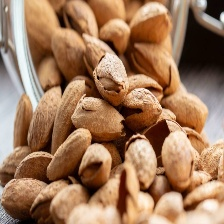

In [15]:
from IPython.display import Image
Image(os.path.join(dir_dict['train_almonds'],'006.jpg'))

# Klassifizierung

In [7]:

for index, row in df.iterrows():
    fname = "{:.0f}.jpg".format(row['class index'])
    
    classname = row['labels']
    if index<3000:
        dest_dir = os.path.join(dir_dict['train'+classname])
    elif index<3500:
        dest_dir = os.path.join(dir_dict['valid'+classname])
    else:
        dest_dir = os.path.join(dir_dict['test'+classname])
        
    src = os.path.join(dir_dict['download'],fname)
    dest = os.path.join(dest_dir,classname+fname)
    shutil.copyfile(src, dest)


KeyError: 'trainalmonds'


# Netzplan

In [9]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(200, 200, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 99, 99, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 48, 48, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 46, 46, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 23, 23, 128)      0

# Eingabe Bilder laden

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(        
        dir_dict['train'],      
        target_size=(200, 200),
        batch_size=20,        
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        dir_dict['valid'],
        target_size=(200, 200),
        batch_size=20,
        class_mode='binary')

Found 3000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


# Startgewichte

In [11]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight('balanced' , np.unique(train_generator.classes), train_generator.classes)

#Patch, nach sklearn update muss das ndarray noch manuell in ein dict objekt konvertiert werden.
class_weights = dict(enumerate(class_weights.flatten(), 0))

print(class_weights)

{0: 2.388535031847134, 1: 0.6323777403035413}


c:\Users\admin\anaconda3\envs\Objecdetection\lib\site-packages\sklearn\utils\validation.py:70: FutureWarning: Pass classes=[0 1], y=[0 0 0 ... 1 1 1] as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


# Traineren

In [12]:
history = model.fit(
      train_generator,
      steps_per_epoch=100, #Hier muss noch noch die Automatische berechnung rein.
      epochs=10, #Extra niedrig gehalten != Vr goes wrooom
      validation_data=validation_generator,
      validation_steps=25,
      class_weight = class_weights)


Epoch 1/10
100/100 [==============================] - 91s 907ms/step - loss: 0.6951 - acc: 0.4880 - val_loss: 0.6755 - val_acc: 0.7720
Epoch 2/10
100/100 [==============================] - 75s 752ms/step - loss: 0.6774 - acc: 0.6285 - val_loss: 0.6259 - val_acc: 0.7760
Epoch 3/10
100/100 [==============================] - 74s 737ms/step - loss: 0.6649 - acc: 0.6485 - val_loss: 0.7227 - val_acc: 0.4720
Epoch 4/10
100/100 [==============================] - 73s 733ms/step - loss: 0.6609 - acc: 0.6170 - val_loss: 0.5538 - val_acc: 0.7600
Epoch 5/10
100/100 [==============================] - 76s 761ms/step - loss: 0.6501 - acc: 0.6315 - val_loss: 0.5797 - val_acc: 0.7500
Epoch 6/10
100/100 [==============================] - 77s 766ms/step - loss: 0.6174 - acc: 0.6905 - val_loss: 0.6118 - val_acc: 0.6900
Epoch 7/10
100/100 [==============================] - 86s 856ms/step - loss: 0.6046 - acc: 0.6980 - val_loss: 0.7015 - val_acc: 0.5720
Epoch 8/10
100/100 [==============================] - 8

#### Lernverlauf auswerten

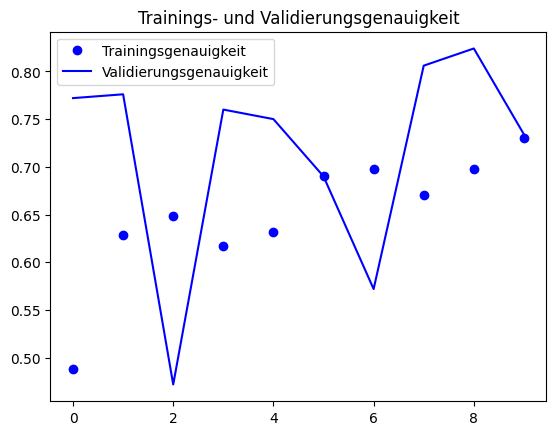

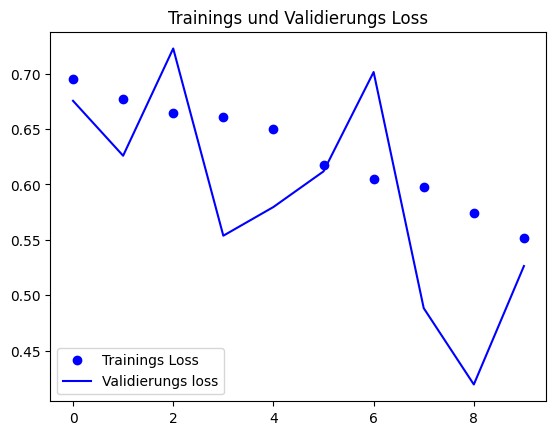

In [13]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Trainingsgenauigkeit')
plt.plot(epochs, val_acc, 'b', label='Validierungsgenauigkeit')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Trainings Loss')
plt.plot(epochs, val_loss, 'b', label='Validierungs loss')
plt.title('Trainings und Validierungs Loss')
plt.legend()

plt.show()

In [14]:
model.save(os.path.join(dir_dict['DataSet'],'DataSet')) #<- Speichert das DataSet.pb im Dataset Ordner
model.save('DataSet.h5')

os.cmd('python -m tf2onnx.convert --saved-model 'os.path.join(dir_dict['DataSet'],'DataSet')' --output model.onnx')

print("Dataset wurde gespeichert für openCV")

SyntaxError: invalid syntax (3530405938.py, line 4)

#### Prädikation

In [ ]:
validation_generator.reset()
prediction = model.predict(validation_generator, verbose=1)

predicted_class_indices = np.argmax(prediction,axis=1)
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

#decoded = decode_predictions(prediction, top=3)[0]


# Lasset uns den Algoritmus arbeiten lassen

In [ ]:
from IPython.display import Image
Image(os.path.join(dir_dict['toDetect'],'Biene.jpg'))